# Feature Distributions & Bin Strategy

In [5]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from build_points_table import build_and_save_points_table
from feature_distributions import add_relative_features, apply_class_groups, feature_percentiles, plot_bin_sweep
from histogram_separability import run_bin_sweep

## Build data

In [ ]:
df = build_and_save_points_table()
df = add_relative_features(df)
df = apply_class_groups(df)

/home/bruno/radar_machine_learning_ws/results/points_table.parquet already covers exactly the requested sequences, skipping build


## Percentiles

In [3]:
feature_percentiles(df)

                  n_points  rcs_p1  rcs_p50  rcs_p99  vr_compensated_p1  vr_compensated_p50  vr_compensated_p99  x_rel_p1  x_rel_p50  x_rel_p99  y_rel_p1  y_rel_p50  y_rel_p99  doppler_spread_p1  doppler_spread_p50  doppler_spread_p99
class                                                                                                                                                                                                                                     
car                 556288  -22.97    -1.35    23.42             -18.42                6.18               23.31     -2.11       0.00       2.25     -1.73       0.00       1.72                0.0                0.00               14.77
large_vehicle       202097  -18.72     3.24    29.97             -18.44                5.58               22.21     -7.01      -0.07       7.81     -3.67      -0.02       3.49                0.0                0.01               14.79
bus                  82494  -21.20    -1.67    25.40        

,n_points,rcs_p1,rcs_p50,rcs_p99,vr_compensated_p1,vr_compensated_p50,vr_compensated_p99,x_rel_p1,x_rel_p50,x_rel_p99,y_rel_p1,y_rel_p50,y_rel_p99,doppler_spread_p1,doppler_spread_p50,doppler_spread_p99
class,,,,,,,,,,,,,,,,
car,556288,-22.974434,-1.353382,23.421806,-18.424654,6.184389,23.314509,-2.105420,0.000000,2.247603,-1.734976,0.000000,1.721992,0.0,0.004425,14.771861
large_vehicle,202097,-18.717138,3.242924,29.965535,-18.442453,5.578499,22.208860,-7.014710,-0.073181,7.806723,-3.665558,-0.017445,3.492631,0.0,0.010012,14.792200
bus,82494,-21.199227,-1.666219,25.404242,-17.214939,5.797098,18.427563,-8.308375,-0.394030,10.409825,-5.783091,-0.030541,5.817387,0.0,0.014425,2.111149
two_wheeler,91088,-25.705622,-10.725831,6.901499,-5.830160,2.566195,10.343635,-0.768036,0.000000,0.860030,-0.671920,0.000000,0.662371,0.0,0.071699,0.961001
pedestrian,137044,-24.439101,-7.258938,7.016496,-2.498820,0.116695,2.775189,-0.404684,0.000000,0.469833,-0.414782,0.000000,0.392651,0.0,0.000000,0.920006
pedestrian_group,366304,-23.071605,-6.204597,7.062467,-2.195420,-0.203393,2.307327,-1.753605,0.000000,1.824931,-1.561212,0.000000,1.593638,0.0,0.108675,0.759126


## Bin count sweep

Saved /home/bruno/radar_machine_learning_ws/results/bin_sweep_rcs.png


Saved /home/bruno/radar_machine_learning_ws/results/bin_sweep_vr_compensated.png


Saved /home/bruno/radar_machine_learning_ws/results/bin_sweep_x_rel.png


Saved /home/bruno/radar_machine_learning_ws/results/bin_sweep_y_rel.png


Saved /home/bruno/radar_machine_learning_ws/results/bin_sweep_doppler_spread.png


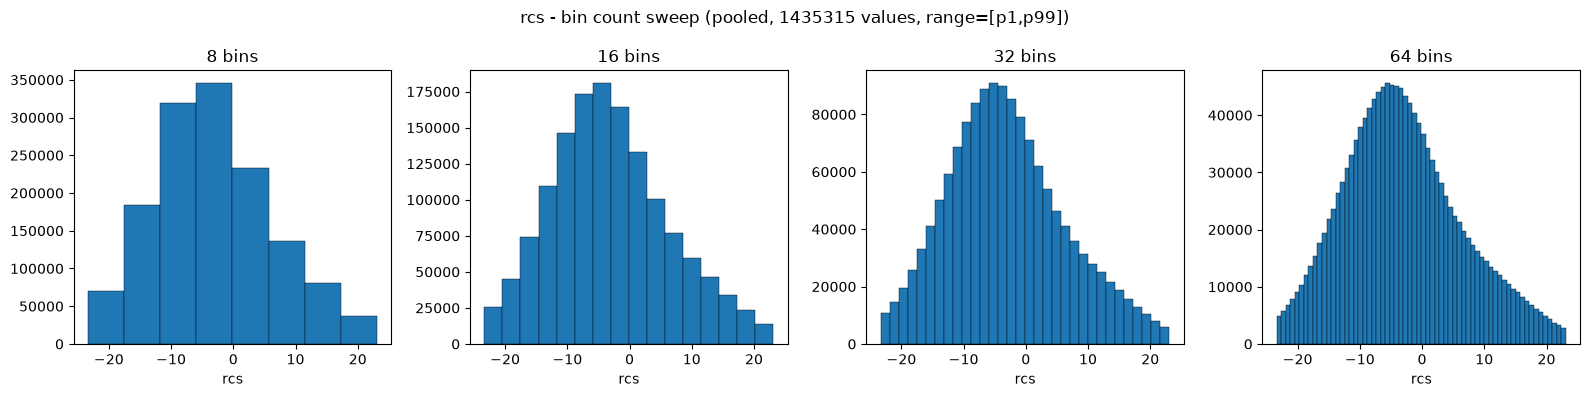

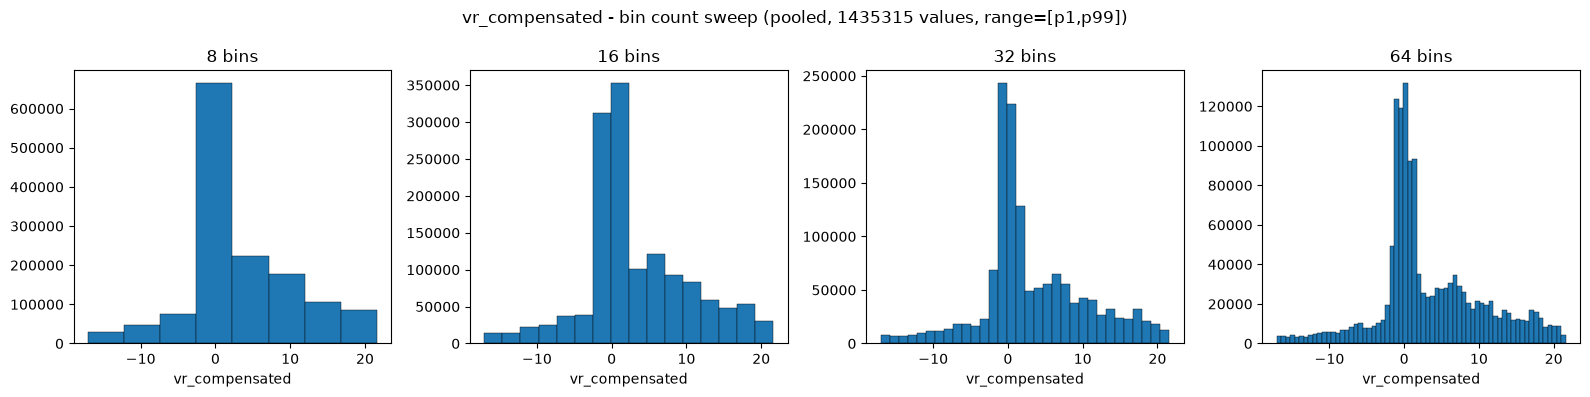

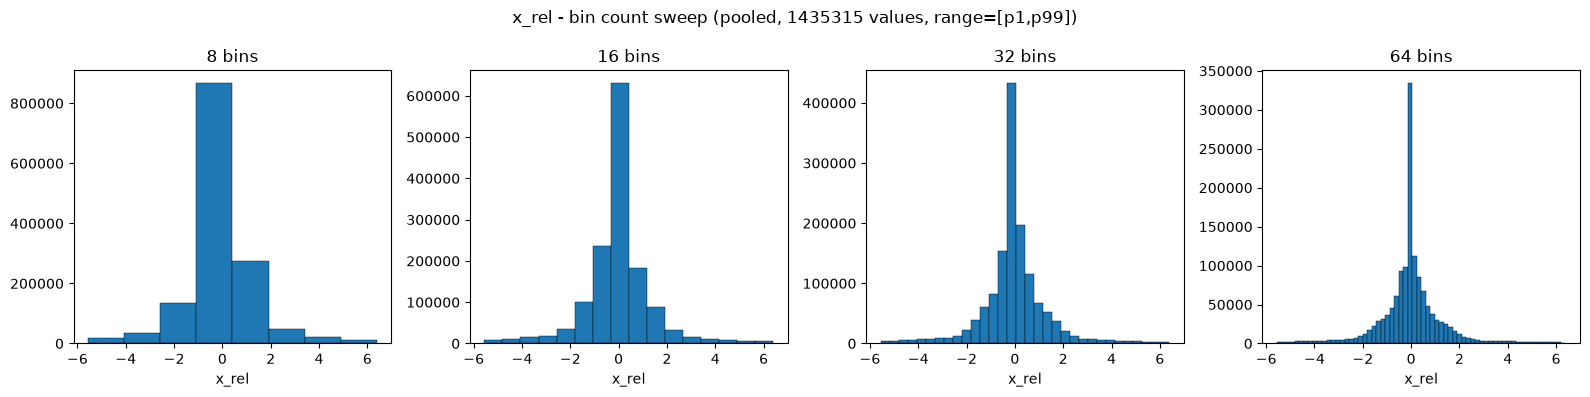

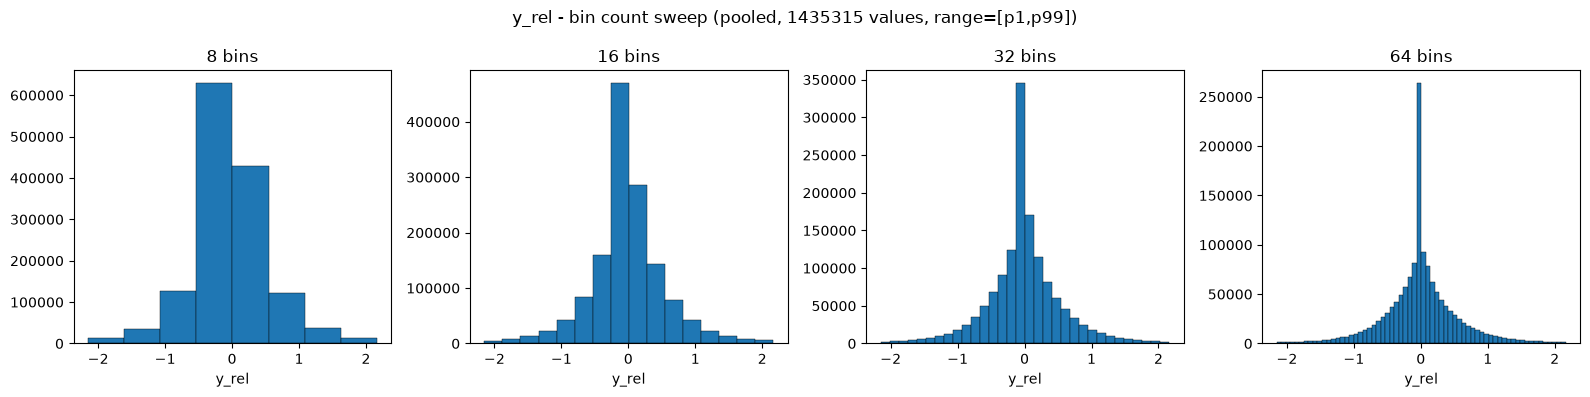

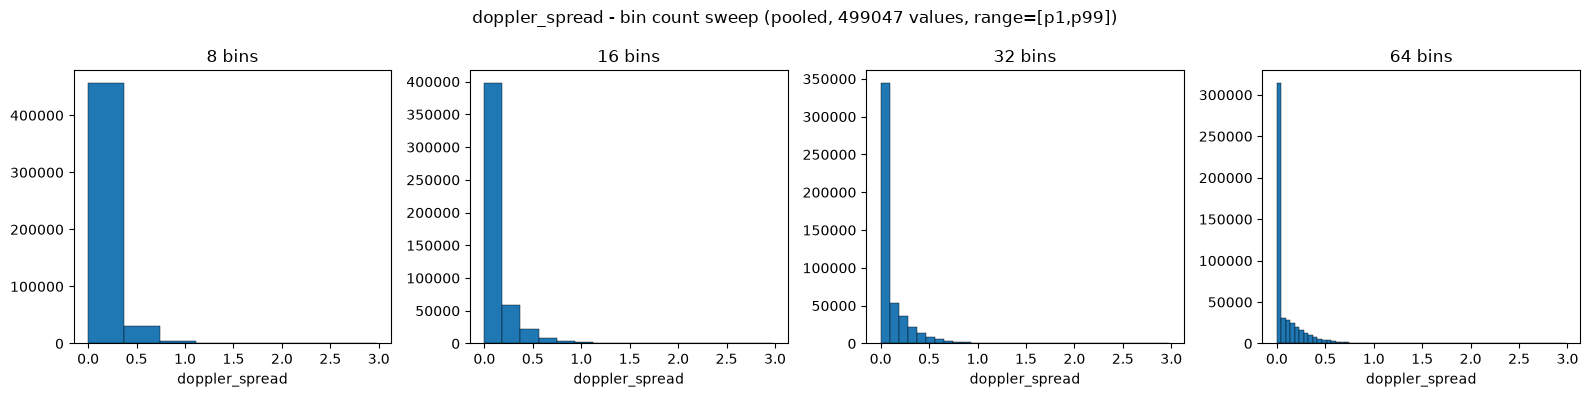

In [4]:
figs = plot_bin_sweep(df)

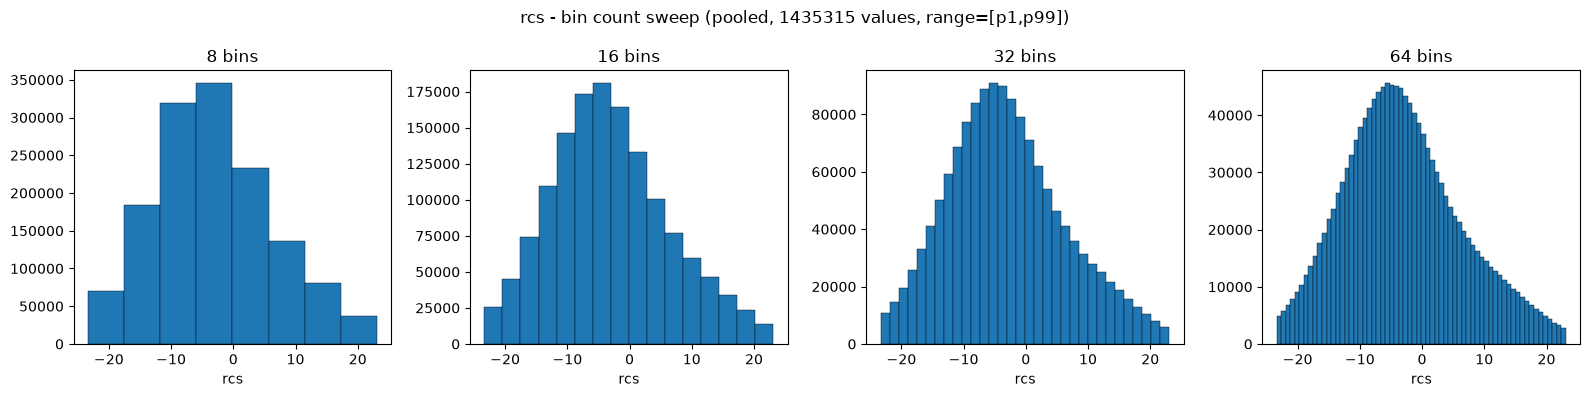

In [5]:
figs["rcs"]

## Bin count sweep via separability probe

Empirical alternative to eyeballing the plots above: builds histogram-encoded per-instance
features at each candidate bin count and scores them with the same sequence-grouped LR+RF
probe used for the taxonomy decision (`separability_probe.run_probe`), rather than judging
resolution from the pooled plots. See `histogram_separability.py`.

In [6]:
run_bin_sweep(df)

/home/bruno/radar_machine_learning_ws/results/bin_sweep_results.parquet already covers bin_counts=(4, 8, 16, 32), skipping sweep
 n_bins               model  macro_auc  auc_bus  auc_car  auc_large_vehicle  auc_pedestrian  auc_pedestrian_group  auc_two_wheeler
      4 logistic_regression      0.883    0.955    0.924              0.834           0.903                 0.882            0.801
      4       random_forest      0.856    0.917    0.918              0.785           0.881                 0.871            0.767
      8 logistic_regression      0.915    0.958    0.941              0.861           0.927                 0.915            0.891
      8       random_forest      0.902    0.941    0.941              0.854           0.912                 0.907            0.860
     16 logistic_regression      0.921    0.958    0.942              0.859           0.939                 0.923            0.903
     16       random_forest      0.919    0.945    0.947              0.874          

,n_bins,model,macro_auc,auc_bus,auc_car,auc_large_vehicle,auc_pedestrian,auc_pedestrian_group,auc_two_wheeler
0,4,logistic_regression,0.883215,0.955311,0.924453,0.833543,0.903491,0.881896,0.800596
1,4,random_forest,0.856462,0.916785,0.918347,0.785264,0.881100,0.870511,0.766767
2,8,logistic_regression,0.915387,0.957664,0.940940,0.860811,0.926947,0.915024,0.890937
3,8,random_forest,0.902498,0.941067,0.941321,0.854068,0.911563,0.906913,0.860057
4,16,logistic_regression,0.920741,0.957763,0.942142,0.859219,0.939216,0.923259,0.902850
5,16,random_forest,0.918541,0.945171,0.947135,0.874431,0.931302,0.922795,0.890413
6,32,logistic_regression,0.922817,0.957781,0.944036,0.857416,0.942511,0.925192,0.909966
7,32,random_forest,0.924670,0.949872,0.947085,0.870049,0.939128,0.930530,0.911354


## Notes

The number of histogram bins was treated as a hyperparameter of the encoding rather than being selected based on the visual characteristics of the resulting histograms. Its effect is better assessed through downstream classification performance, as the purpose of the encoding is to provide informative features for the classifier.

For the initial implementation, a provisional bin count is required. Given the observed average of approximately 2.87 radar points per instance, a relatively small number of bins, such as 4–8, was considered more appropriate than larger values such as 32 or 64. This value is not regarded as final and can be revised following empirical evaluation, using the existing taxonomy_separability.py probe with histogram-encoded features, similar to what was done decide wether to group some classes. Different bin counts can be compared using the same leakage-safe (aka per full sequence) cross-validation and AUC metric, allowing the final value to be selected based on classification performance.